# **Análisis y Predicción de Ventas**

**Objetivo:**  Predecir las ventas futuras basándose en varias características que describen productos, categorías y fechas de venta


**Dataset:** https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset


**Descripción del Dataset**: Este conjunto de datos contiene datos históricos de ventas de retail, incluidos detalles sobre las ventas diarias de diversas categorías de productos.


**Diccionario de Datos**
|**Columna**|**Descripcion**|
|:---|:---|
|Transaction ID| Identificador único para cada transacción|
|Date|Fecha en que ocurrió la transacción|
|Customer ID| Identificador único para cada cliente|
|Gender|Género del cliente (Masculino/Femenino)|
|Age|Edad del cliente|
|Product Category|Categoría del producto comprado (Electrónica, Ropa, Belleza)|
|Quantity|Número de unidades del producto comprado|
|Price per Unit| Precio por unidad del proaducto comprado|
|Total Amount| Cantidad total = precio por unidad * cantidad|


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

# Paleta de colores para gráficos posteriores
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'
print('Importaciones realizadas con exito!')

Importaciones realizadas con exito!


> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [2]:
df = pd.read_csv('/content/sample_data/retail_sales_dataset.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 1000 filas x 9 columnas
Memoria aproximada: 260 KB

Columnas: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [3]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



=== Ultimas 5 filas ===


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


El dataset tienen 9 columnas, 5 con valores numericos y 4 tipo object.

Aparentemente sin nulos


> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [5]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000



=== Columnas categoricas ===


,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST1000,Female,Clothing
freq,11,1,510,351


Categoria con tres valores unicos , siendo la mas vendida Clothing, Genero que mas compra Femenino.

Edades entre 18 y 64, Cantidades entre 1 y 4, precio por unidad entre 25y 500.


# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [6]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object



In [7]:
# trabajo en una copia del dataset
df_clean = df.copy()

# 'Date' debe ser datetime, no texto
df_clean['Date'] = pd.to_datetime(df['Date'])

# 'Gender' y 'Product Category' deben ser categóricas
df_clean['Gender'] = df_clean['Gender'].astype('category')
df_clean['Product Category'] = df_clean['Product Category'].astype('category')

print('Tipos de Datos despues de limpiar:')
print(df_clean.dtypes)

Tipos de Datos despues de limpiar:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                    category
Age                          int64
Product Category          category
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


> ## <font color='1890A3'>**Paso 2.2 Identificar y eliminar duplicados**</font>

In [8]:
# n_total = len(df_clean)
n_dupes_total = df_clean.duplicated().sum()
print(f'Filas duplicadas (todas las columnas): {n_dupes_total}')

# Duplicados por Transaction ID
n_dupes_id = df_clean['Transaction ID'].duplicated().sum()
print(f'Transaction ID duplicados: {n_dupes_id}')

if n_dupes_total > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f'Filas tras eliminar duplicados: {len(df)}')
else:
    print('No hay filas duplicadas, no se elimina ninguna')

Filas duplicadas (todas las columnas): 0
Transaction ID duplicados: 0
No hay filas duplicadas, no se elimina ninguna


> ## <font color='#1890A3'> **Paso 2.3 Inconsistencias en valores categoricos** </font>

In [9]:
# valores únicos en columnas categóricas
for col in ['Gender', 'Product Category']:
    print(f'{col}: {sorted(df_clean[col].unique())}')

# normalizacion de formato
for col in ['Gender', 'Product Category']:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
    df_clean[col] = df_clean[col].astype('category')

print('\nDespués de normalizar:')
for col in ['Gender', 'Product Category']:
    print(f'{col}: {sorted(df_clean[col].unique())}')

Gender: ['Female', 'Male']
Product Category: ['Beauty', 'Clothing', 'Electronics']

Después de normalizar:
Gender: ['Female', 'Male']
Product Category: ['Beauty', 'Clothing', 'Electronics']


Columnas con baja cardinalidad y sin nulos

>

> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [10]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral


Dataset sin valores nulos

> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

In [34]:
filas_antes = len(df_clean)

print('----- ANALISIS DE OUTLIERS -----')
print()
# --- Valores imposibles en edad: no pueden ser negativos o menores a 18 ---
edades_invalidas = df_clean[(df_clean['Age'] <= 0) | (df_clean['Age'] < 18)]
print(f'Edades con valores imposibles (menores a 18 o negativas): {len(edades_invalidas)} filas')

# --- Total Amount (variable objetivo): usamos IQR para detectar extremos ---
q1_p, q3_p = df_clean['Total Amount'].quantile([0.25, 0.75])
iqr_p = q3_p - q1_p
lim_total = q3_p + 1.5 * iqr_p
outliers_total = df_clean[df_clean['Total Amount'] > lim_total]

print(outliers_total[['Product Category', 'Quantity', 'Price per Unit', 'Total Amount']]
      .sort_values(by='Total Amount', ascending=False).head(10))
print(f'\nTotal Amount (Variable Objetivo):')
print(f'Q1={q1_p:.0f}  Q3={q3_p:.0f}  IQR={iqr_p:.0f}  Limite IQR={lim_total:.0f}')
print(f'Transacciones con Total Amount > limite IQR: {len(outliers_total)} ({len(outliers_total)/len(df_clean)*100:.1f}%)')
print(f'No se detectan transacciones por sobre el limite IQR')
print(f'Decisión: No hay outliers que tratar en Total Amount segun el criterio IQR')

print(f'\nFilas eliminadas en la depuración de Outliers: {filas_antes - len(df_clean)}')
print(f'Dataset limpio final: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas')
print(f'Nulos totales en el dataset: {df_clean.isnull().sum().sum()}')

----- ANALISIS DE OUTLIERS -----

Edades con valores imposibles (menores a 18 o negativas): 0 filas
Empty DataFrame
Columns: [Product Category, Quantity, Price per Unit, Total Amount]
Index: []

Total Amount (Variable Objetivo):
Q1=60  Q3=900  IQR=840  Limite IQR=2160
Transacciones con Total Amount > limite IQR: 0 (0.0%)
No se detectan transacciones por sobre el limite IQR
Decisión: No hay outliers que tratar en Total Amount segun el criterio IQR

Filas eliminadas en la depuración de Outliers: 0
Dataset limpio final: 1000 filas x 8 columnas
Nulos totales en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Inncesarias** </font>
Se eliminan las columnas que son identificadores ya que no aportan valor predictivo: `Transaction ID` y `Customer ID`

In [12]:
df_clean = df_clean.drop(columns=['Transaction ID', 'Customer ID'])

> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [13]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 1000 filas x 7 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
int64             4
datetime64[ns]    1
category          1
category          1
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**VISUALIZACIONES UNIVARIANTES**</font>



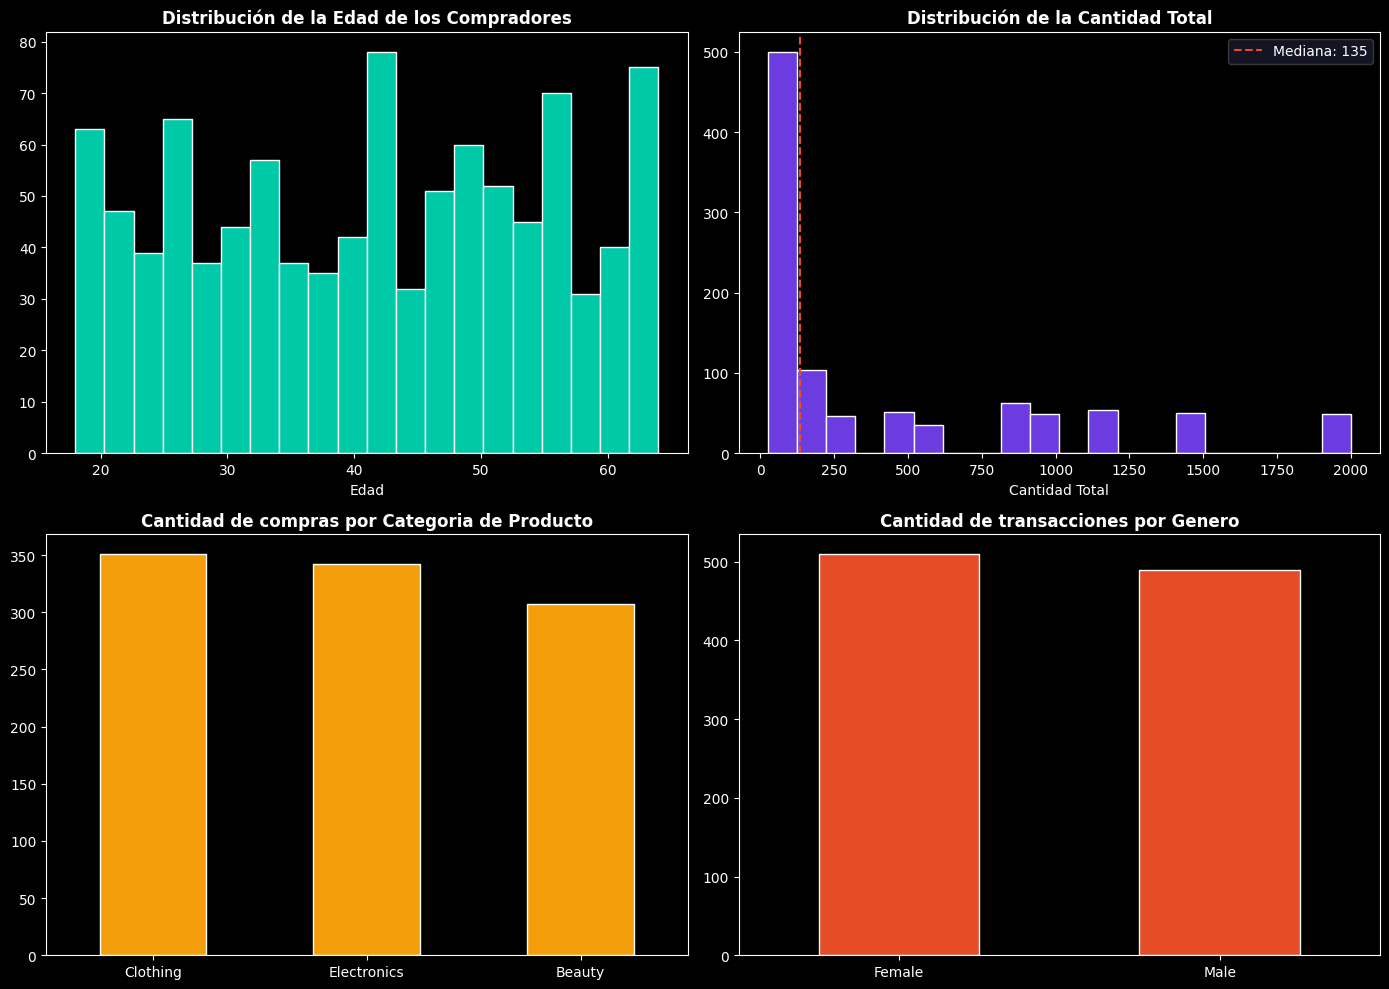

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de edad
axes[0, 0].hist(df_clean['Age'], bins=20, color=TEAL, edgecolor='white')
axes[0, 0].set_title('Distribución de la Edad de los Compradores', fontweight='bold')
axes[0, 0].set_xlabel('Edad')

# Histograma de Total Amount
axes[0, 1].hist(df_clean['Total Amount'], bins=20, color=PURPLE, edgecolor='white')
axes[0, 1].axvline(df_clean['Total Amount'].median(), color=RED, linestyle='--',
                    label=f"Mediana: {df_clean['Total Amount'].median():.0f}")
axes[0, 1].set_title('Distribución de la Cantidad Total', fontweight='bold')
axes[0, 1].set_xlabel('Cantidad Total')
axes[0, 1].legend()

# BarPlot Product Category
df_clean['Product Category'].value_counts().plot(kind='bar', ax=axes[1, 0], color=AMBER, edgecolor='white')
axes[1, 0].set_title('Cantidad de compras por Categoria de Producto', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)

# BarPlot de Genero de los compradores
df_clean['Gender'].value_counts().plot(kind='bar', ax=axes[1, 1], color=RED, edgecolor='white')
axes[1, 1].set_title('Cantidad de transacciones por Genero', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



> **Analisis**

`Total Amount`: La distribucion esta sesgada a la derecha, con un pico cerca del cero y pequenos saltos en valores mas altos. Esto indica que la mayoria de las ventas son por montos bajos, y las ventas de montos altos son excepcionales.

`Product Category`: La mayoria de las ventas se concentran en la categoria Clothing, seguido de cerca por Electronics y en ultimo lugar Beauty.

`Gender`: Las mujeres dominan por poco margen a los hombres en el genero de los compradores.

`Age`: Tiene una distribucion uniforme, cada barra tiene entre 20 y 30 registros por cada rango de edad, lo que indica que no hay un segmento de edad que domine las ventas.

> ## <font color='#1890A3'>**Visualizacion Multivariantes  --Boxplots**</font>

**Objetivo:** Ver la relacion entre la cantidad total de ventas y la edad y genero de los compradores

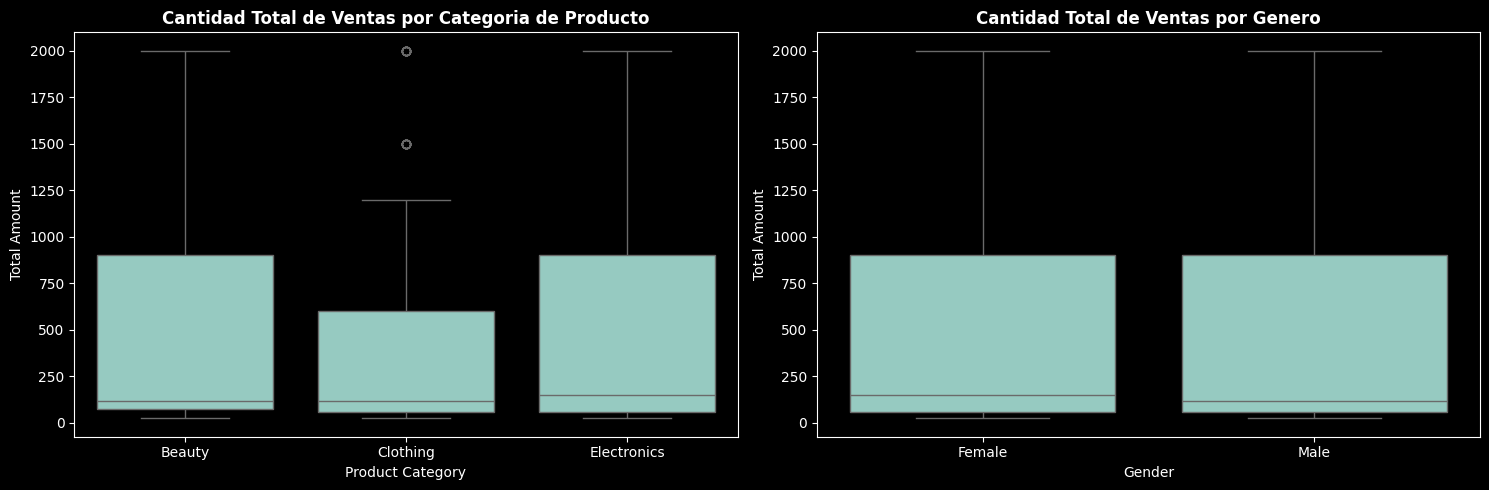

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot Total Amount por Product Category
sns.boxplot(data=df_clean, x='Product Category', y='Total Amount', ax=axes[0])
axes[0].set_title('Cantidad Total de Ventas por Categoria de Producto', fontweight='bold')

# Boxplot Total Amount por Gender
sns.boxplot(data=df_clean, x='Gender', y='Total Amount', ax=axes[1])
axes[1].set_title('Cantidad Total de Ventas por Genero', fontweight='bold')

plt.tight_layout()
plt.show()


>**Analisis**

No existe diferencia  notable entre las cantidad de dinero gastada por las mujeres y por los hombres.

La cantidad total de ventas de Beauty y Electronics estan en el mismo rango, la de Clothing un poco por debajo. Las medianas estan alrededor de los 150 usd, es decir que la mayoria de las ventas son de bajo valor.

Se observan outliers en la categoria de clothing, posiblemente debido a una compra de muchas unidades de algun producto especifico o un producto muy costoso, pero no definen el comportamiento promedio de los clientes de la tienda.

> ## <font color='#1890A3'>**Visualizacion Multivariante 2 -- LinePlot de Cantidad Total de Ventas por mes**</font>

**Objetivo:** Indagar si las ventas tienen algun patron estacional

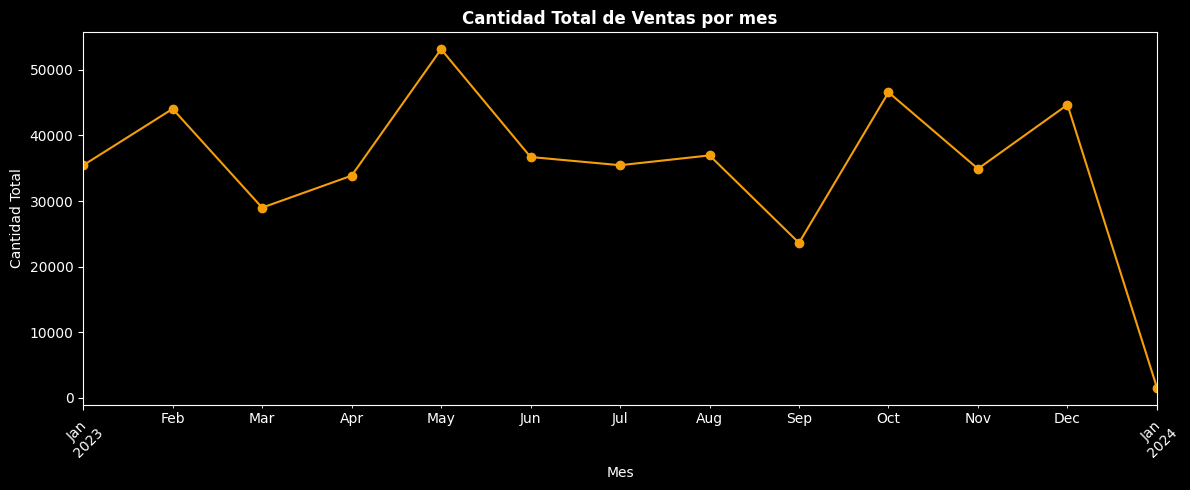

In [29]:
# Total Amount promedio por mes
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
ventas_mensuales = df_clean.groupby('Month')['Total Amount'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ventas_mensuales.plot(kind='line', marker='o', ax=ax, color=AMBER)
ax.set_title('Cantidad Total de Ventas por mes', fontweight='bold')
ax.set_ylabel('Cantidad Total')
ax.set_xlabel('Mes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Analisis**

No se observa una tendencia mensual marcada, las ventas oscilan en todo el periodo sin mostrar estacionalidad, con algunos picos en Mayo, Octubre y Noviembre, y una caida significativa en el ultimo mes.

la mayoria de las ventas oscila entre los 2250 y 5200 usd.

Como no se observa una estacionalidad clara y son solo los datos de un anio, no se incorporara el tiempo en el modelado.

> ## <font color='#1890A3'>**HEatmap de variables numericas independientes**</font>

**Objetivo:** Ver la relacion entre las variables numericas para determinar su relacion con la variable objetivo

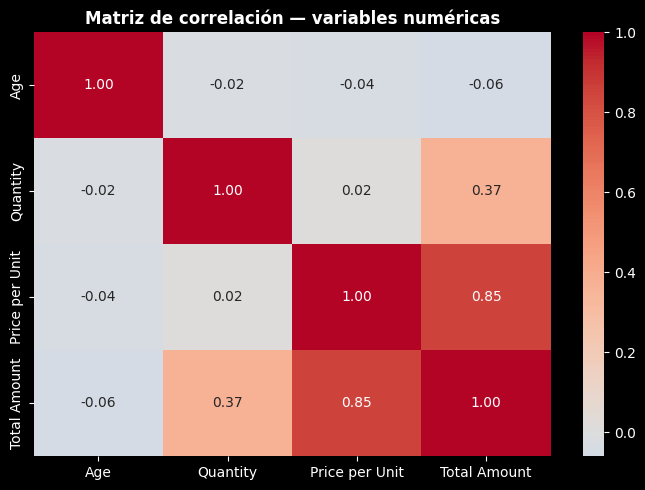

In [33]:
# Mapa de calor de correlaciones entre variables numéricas
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación — variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

>**Analisis**

- **`age`:** Correlacion practicamente nula, -0.06

- **`Quantity`:** Correlacion positiva media, 0.37.

- **`Price per unit`:** Correlacion positiva alta,0.85.

**Conclusión:** La cantidad total de ventas no depende de la edad del cliente. Obviamente comprar mas cantidad de productos va a incrementar la cantidad total, pero la correlacion no es tan fuerte porque a la final depende del precio del producto. El precio por unidad es el principal determinante de `Total Amount` lo cual es logico ya que Total Amount = Quantity * Price per unit



# <font color='#1890A3'> **SECCION 4 PREPROCESAMIENTO DE DATOS**
**Agrupacion | Encoding | Train/Test | Escalamiento** </font>

> ## <font color='#1890A3'>**4.1 Definicion de features y target**</font>

**Target:**`Total Amount`

**Features:** `Gender`, `Age`, `Product Category`,`Price per Unit`.

Se excluye `Date` ya que la variable no muestra estacionalidad

In [42]:
df_prep = df_clean.copy()
TARGET = 'Total Amount'

X = df_prep[['Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit']]
y = df_prep[TARGET]

cols_cat = X.select_dtypes(exclude='number').columns.tolist()
cols_num = X.select_dtypes(include='number').columns.tolist()

print(f'Categóricas ({len(cols_cat)}): {cols_cat}')
print(f'Numéricas ({len(cols_num)}): {cols_num}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Categóricas (2): ['Gender', 'Product Category']
Numéricas (3): ['Age', 'Quantity', 'Price per Unit']

Train: (800, 5)  |  Test: (200, 5)


> ## <font color='#1890A3'>**4.2 Column Transformer con Imputacion + Escalado/Encoding por tipo de feature**</font>

In [43]:
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # por ser variables categoricas
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocesador = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])
print('Preprocesador Listo')

Preprocesador Listo


# <font color='#1890A3'> **SECCION 5  ENTRENAMIENTO Y EVALUACION DE MODELOS**

**Random Forest Regressor| Decision Tree Regressor** </font>

> ## <font color='#1890A3'>**5.1 Decision Tree Regressor**</font>

In [44]:
pipe_tree = Pipeline([
    ('prep', preprocesador),
    ('mod',  DecisionTreeRegressor(random_state=42))
])

param_grid_tree = {
    'mod__max_depth': [3, 5, 7, 10, None],
    'mod__min_samples_split': [2, 5, 10],
    'mod__min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    pipe_tree, param_grid_tree,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_tree.fit(X_train, y_train)

print(f'Decision Tree Regresor - Resultados iniciales: {grid_tree.best_params_}')
print(f'   Mejor R² (CV en train):  {grid_tree.best_score_:.4f}')
print(f'   R² en TEST:              {grid_tree.score(X_test, y_test):.4f}')

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Decision Tree Regresor - Resultados iniciales: {'mod__max_depth': 5, 'mod__min_samples_leaf': 1, 'mod__min_samples_split': 2}
   Mejor R² (CV en train):  1.0000
   R² en TEST:              1.0000


> ## <font color='#1890A3'>**5.2 Random Forest Regression**</font>

In [45]:
pipe_rf = Pipeline([
    ('prep', preprocesador),
    ('mod',  RandomForestRegressor(random_state=42, n_jobs=-1))
])

pipe_rf.fit(X_train, y_train)

print('Random Forest Resultados Iniciales:')
print(f'   R² en TRAIN: {pipe_rf.score(X_train, y_train):.4f}')
print(f'   R² en TEST:  {pipe_rf.score(X_test, y_test):.4f}')

Random Forest Resultados Iniciales:
   R² en TRAIN: 1.0000
   R² en TEST:  1.0000


>**Analisis**

Los modelos **"Random Forest** y **Decision Tree** con un R2 = 1, indican que lograron capturar automáticamente la relación entre Total Amount = Quantity * Price per Unit.


# <font color='#1890A3'> **SECCION 6 OPTIMIZACION DE HIPERPARAMETROS**

> ## <font color='#1890A3'>**6.1 GridSEarchCV para Decision Tree Regression**</font>

In [46]:
param_grid_tree = {
    'mod__max_depth': [3, 5, 7, 10, None],
    'mod__min_samples_split': [2, 5, 10],
    'mod__min_samples_leaf': [1, 2, 5]
}

grid_tree = GridSearchCV(
    pipe_tree, param_grid_tree,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_tree.fit(X_train, y_train)

print(f'Decision Tree Tuneado Mejores Hiperparametros: {grid_tree.best_params_}')
print(f'   Mejor R² (CV en train):  {grid_tree.best_score_:.4f}')
print(f'   R² en TEST:              {grid_tree.score(X_test, y_test):.4f}')

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Decision Tree Tuneado Mejores Hiperparametros: {'mod__max_depth': 5, 'mod__min_samples_leaf': 1, 'mod__min_samples_split': 2}
   Mejor R² (CV en train):  1.0000
   R² en TEST:              1.0000


> ## <font color='#1890A3'>**6.2 GridSEarchCV para Random Forest Regression**</font>

In [47]:
param_grid_rf = {
    'mod__n_estimators': [100, 200],
    'mod__max_depth': [5, 10, None],
    'mod__min_samples_leaf': [1, 2, 5]
}

grid_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print(f'Random Forest Tuneado Mejores Hiperparametros: {grid_rf.best_params_}')
print(f'   Mejor R² (CV en train):  {grid_rf.best_score_:.4f}')
print(f'   R² en TEST:              {grid_rf.score(X_test, y_test):.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest Tuneado Mejores Hiperparametros: {'mod__max_depth': 10, 'mod__min_samples_leaf': 1, 'mod__n_estimators': 100}
   Mejor R² (CV en train):  1.0000
   R² en TEST:              1.0000


>**Analisis**

Obviamente la hiperparametrizacion no me va a generar un resultado mejor, ya r2 habia obtenido un valor inicial de 1 en ambos modelos.

Sin embargo, se observa que los hiperparámetros que selecciona el GridSearch (por ejemplo, max_depth no muy alto, min_samples_leaf bajo) son coherentes con la simplicidad real del problema: **Total Amount = Quantity × Price per Unit**, los modelos no necesitan mucha complejidad (árboles muy profundos o muchos estimadores) para llegar al ajuste perfecto, y el GridSearch lo refleja eligiendo configuraciones relativamente simples.

# <font color='#1890A3'> **Comparacion de Modelos**
 </font>

In [48]:
def evaluar(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    return {'Modelo': nombre, 'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}

resultados = pd.DataFrame([
    evaluar(grid_tree.best_estimator_, X_test, y_test, 'Decision Tree'),
    evaluar(grid_rf.best_estimator_,   X_test, y_test, 'Random Forest'),
]).set_index('Modelo')

resultados.round(3)

,R2,MAE,MSE,RMSE
Modelo,,,,
Decision Tree,1.0,0.0,0.0,0.0
Random Forest,1.0,0.0,0.0,0.0


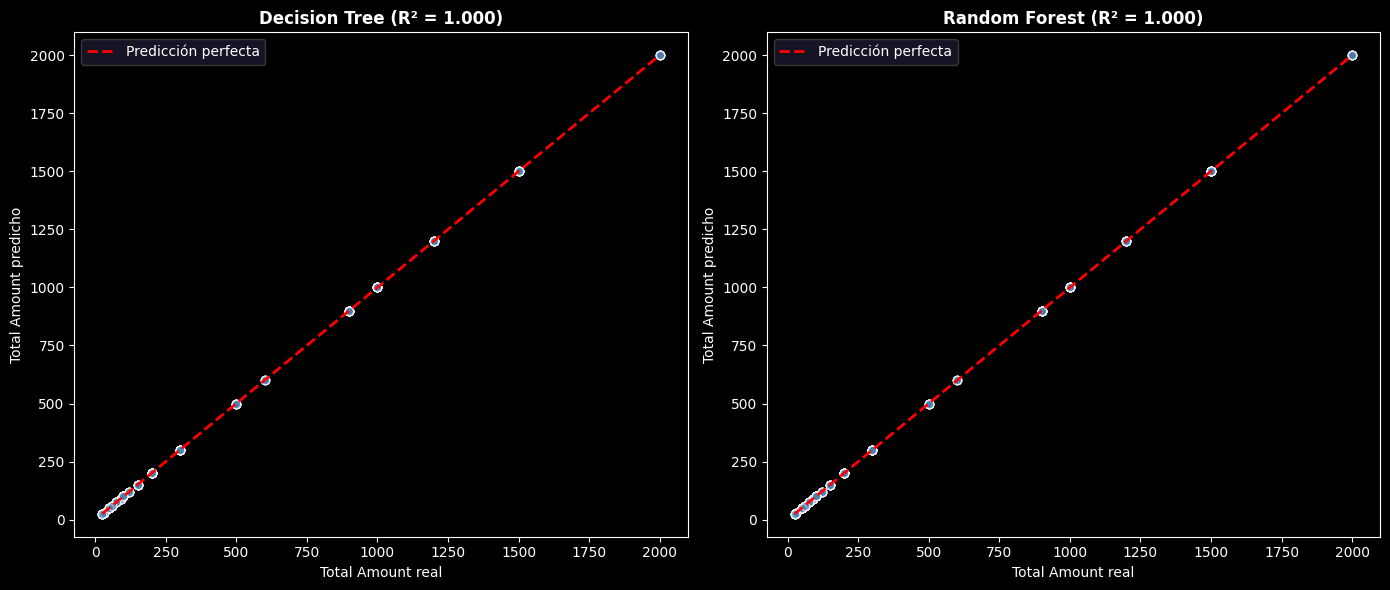

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (modelo, nombre) in zip(axes, [(grid_tree.best_estimator_, 'Decision Tree'),
                                         (grid_rf.best_estimator_, 'Random Forest')]):
    y_pred = modelo.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='white')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Predicción perfecta')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{nombre} (R² = {r2:.3f})', fontweight='bold')
    ax.set_xlabel('Total Amount real')
    ax.set_ylabel('Total Amount predicho')
    ax.legend()

plt.tight_layout()
plt.show()

>**Analisis**
Dado los resultados obtenidos con parametros perfectos, las predicciones que hacen los modelos son perfectas

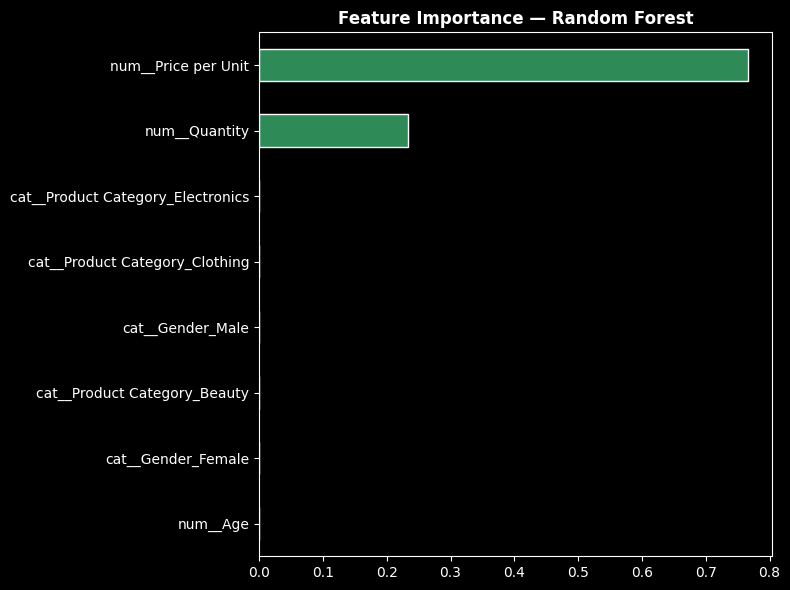

In [50]:
# Feature importance
nombres_features = grid_rf.best_estimator_.named_steps['prep'].get_feature_names_out()
importancias = pd.Series(
    grid_rf.best_estimator_.named_steps['mod'].feature_importances_,
    index=nombres_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind='barh', color='seagreen', edgecolor='white', ax=ax)
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

>**Analisis**

Tal como lo habiamos visto en la matriz de correlacion, solo `Quantity` y `Price per unit` son las features que influyen en la determinacion de `Total Amount`, por la forma en la que esta es calculada

## **Resumen de Hallazgos y Conclusiones**

### Hallazgos principales

- **Dataset:** sin valores duplicados ni nulos. No se detectaron edades imposibles (<18 años) ni outliers en `Total Amount` según el criterio IQR.

- **Correlaciones con el target (`Total Amount`):**
  - `Price per Unit`: correlación positiva alta (**0.85**) — es la variable que más explica el monto total.
  - `Quantity`: correlación positiva moderada (**0.37**) con valores entre 1 y 4.
  - `Age`: correlación prácticamente nula (**-0.06**).

- **Resultado de los modelos:** tanto ***DecisionTreeRegressor*** como ***RandomForestRegressor*** alcanzaron **R² = 1.0**, en el modelo inicial y obviamente despues de aplicar GridSearchCV.

- **Causa del R² = 1:** `Total Amount = Quantity × Price per Unit` es una relacion **exacta y determinística**. Como ambas variables están incluidas como features, y tienen un número reducido de valores posibles, los árboles pueden reproducir esta multiplicación con muy pocos splits — no están "generalizando", están reconstruyendo una fórmula.

- **GridSearchCV:** no mejora el R² (1.0 es el máximo valor posible), pero selecciona configuraciones de hiperparámetros relativamente simples — coherente con la baja complejidad real del problema.

- **`Date`** se excluyó del modelado. El EDA mostró picos y valles mensuales, pero con un solo año de datos no es posible confirmar estacionalidad real (patrón que se repita año tras año).

### Conclusiones

1. Los modelos de árboles funcionaron de manera óptima para este dataset lo cual refleja que el problema, tal como está planteado, es prácticamente determinístico, no una limitación de los modelos.

2. Variables como `Age`, `Gender` y `Product Category` tienen aporte nulo para predecir `Total Amount`, ya que el target no depende de ellas — depende exclusivamente de `Quantity` y `Price per Unit`.

4. El dataset, tal como está estructurado, parece más apto para **análisis descriptivo, segmentación o problemas de clasificación** que para regresión de `Total Amount`, dado que el target elegido es una transformación matemática directa de variables ya presentes en los datos.

### Recomendaciones

- **No usar este enfoque (predecir `Total Amount` con `Quantity` y `Price per Unit` como inputs) en un escenario productivo real**, ya que no aporta valor predictivo — equivale a automatizar una multiplicación.

- **Redefinir la pregunta de negocio** si se desea un problema de regresión con valor analítico real, por ejemplo:
  - Predecir `Quantity` (casi una clasificación de 4 clases) a partir de `Age`, `Gender`, `Product Category` y `Price per Unit`, para entender patrones de comportamiento de compra.
  - Predecir `Total Amount` **sin** incluir `Quantity` ni `Price per Unit`, usando solo variables demográficas/categóricas — aunque el R² esperado sería muy bajo o negativo porque en el EDA se vio que la correlacion es casi nula, mediría cuánto explican realmente esas variables.

- **Para análisis de estacionalidad**, recopilar al menos 2-3 años de datos que permitan comparar el mismo mes entre años distintos.

### ¿Para qué podría ser útil este modelo?

- **Verificador/auditor de datos**: si en producción llegaran registros donde `Total Amount ≠ Quantity × Price per Unit`, el modelo entrenado podría usarse para **detectar inconsistencias o errores de captura** en transacciones nuevas (residuos grandes = posible error de digitación).
